# ![Machine Learning Lab](banner.jpg)

# Laboratorio 8 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab8.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar una Red Neuronal Convolucional (CNN) para clasificación de imágenes médicas.
2. Aplicar técnicas de preprocesamiento y aumentación de datos a imágenes.
3. Evaluar y comparar el desempeño del modelo con y sin data augmentation.

---

En esta ocasión trabajaremos con el dataset **Brain Tumor MRI Images**, que contiene imágenes de resonancia magnética cerebral clasificadas en 4 categorías: **Glioma**, **Meningioma**, **Pituitary** y **Healthy**.

Dataset: [Brain Tumor MRI Images](https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download("miadul/brain-tumor-mri-dataset")
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Visualiza al menos 3 imágenes de ejemplo de cada clase en una cuadrícula.
4. Muestra la distribución de clases en un gráfico de barras. ¿El dataset está balanceado?

---

### 2. Preprocesamiento de datos (20%)

1. Redimensiona todas las imágenes a un tamaño uniforme (por ejemplo, 150×150 píxeles).
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

---

### 3. Modelo CNN base (30%)

1. Construye una CNN con al menos 3 bloques convolucionales (Conv2D + MaxPooling2D).
2. Agrega capas Dense para la clasificación final.
3. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
4. Compila el modelo con el optimizador y función de pérdida adecuados para clasificación multiclase.
5. Entrena el modelo.
6. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).

---

### 4. Data Augmentation (30%)

1. Define una estrategia de aumentación de datos que incluya al menos 3 transformaciones (rotación, volteo, zoom, etc.).
2. Visualiza el efecto de la aumentación sobre algunas imágenes de ejemplo.
3. Construye un nuevo modelo CNN que integre las capas de aumentación.
4. Entrena el modelo.
5. Grafica las curvas de aprendizaje del modelo con aumentación.
6. Compara la precisión del modelo con y sin aumentación en el conjunto de prueba.

---

### 5. Análisis de resultados (10%)

1. Genera la matriz de confusión para ambos modelos (con y sin aumentación).
2. ¿Cuáles tipos de tumor son más difíciles de clasificar?
3. Reporta la precisión (accuracy), precisión por clase y recall por clase para el mejor modelo.

---


# **1. Carga y exploración de datos**

In [17]:
import os

os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.8"

In [18]:
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import numpy as np
import kagglehub
import shutil
import random
import os

In [19]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Descarga del conjunto de datos a utilizar haciendo uso de la libreria **kagglehub** con el fin de automatizar el proceso y hacer que sea replicable

In [20]:
dataset_path = kagglehub.dataset_download(handle = "miadul/brain-tumor-mri-dataset", output_dir = "../datasets", force_download = True)
print(f"DATASET DOWNLOADED IN: {dataset_path}")

100%|██████████| 236M/236M [00:06<00:00, 38.3MB/s] 

Extracting files...


DATASET DOWNLOADED IN: ../datasets


Exploración de la estructura de carpetas del conjunto de datos descargado anteriormente

In [21]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])
    if num_files > 0:
        print(f"{indent}{folder_name}/ ({num_files} imágenes)")
    else:
        print(f"{indent}{folder_name}/")

datasets/
  .complete/
    datasets/
      miadul/
        brain-tumor-mri-dataset/
          1/
  brain_tumor_dataset/
    pituitary/ (1757 imágenes)
    glioma/ (1621 imágenes)
    meningioma/ (1645 imágenes)
    healthy/ (2000 imágenes)


Reorganización de la estructura de carpetas con el fin de cumplir con la estructura necesaria para utilizar la herramienta **image_dataset_from_directory**

In [22]:
root_path = "../datasets"
hidden_path = os.path.join(root_path, ".complete")
former_path_classes = os.path.join(root_path, "brain_tumor_dataset")

In [23]:
classes = ["glioma", "healthy", "meningioma", "pituitary"]

In [24]:
if os.path.exists(hidden_path):
    shutil.rmtree(hidden_path)
    print(f"Folder '{hidden_path}' deleted")

for name in classes:
    origin = os.path.join(former_path_classes, name)
    destination = os.path.join(root_path, name)
    
    if os.path.exists(origin):
        shutil.move(origin, destination)
        print(f"☑ Class '{name}' moved to root")

if os.path.exists(former_path_classes):
    shutil.rmtree(former_path_classes)
    print(f"Intermediate folder '{former_path_classes}' deleted")

Folder '../datasets/.complete' deleted
☑ Class 'glioma' moved to root
☑ Class 'healthy' moved to root
☑ Class 'meningioma' moved to root
☑ Class 'pituitary' moved to root
Intermediate folder '../datasets/brain_tumor_dataset' deleted


Verificación de la nueva estructura de carpetas del conjunto de datos

In [25]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])
    if num_files > 0:
        print(f"{indent}{folder_name}/ ({num_files} imágenes)")
    else:
        print(f"{indent}{folder_name}/")

datasets/
  pituitary/ (1757 imágenes)
  glioma/ (1621 imágenes)
  meningioma/ (1645 imágenes)
  healthy/ (2000 imágenes)


Visualización de 4 imágenes aleatorias por cada clase del conjunto de datos

In [26]:
data_dir = Path("../datasets") 
classes = ["glioma", "healthy", "meningioma", "pituitary"]

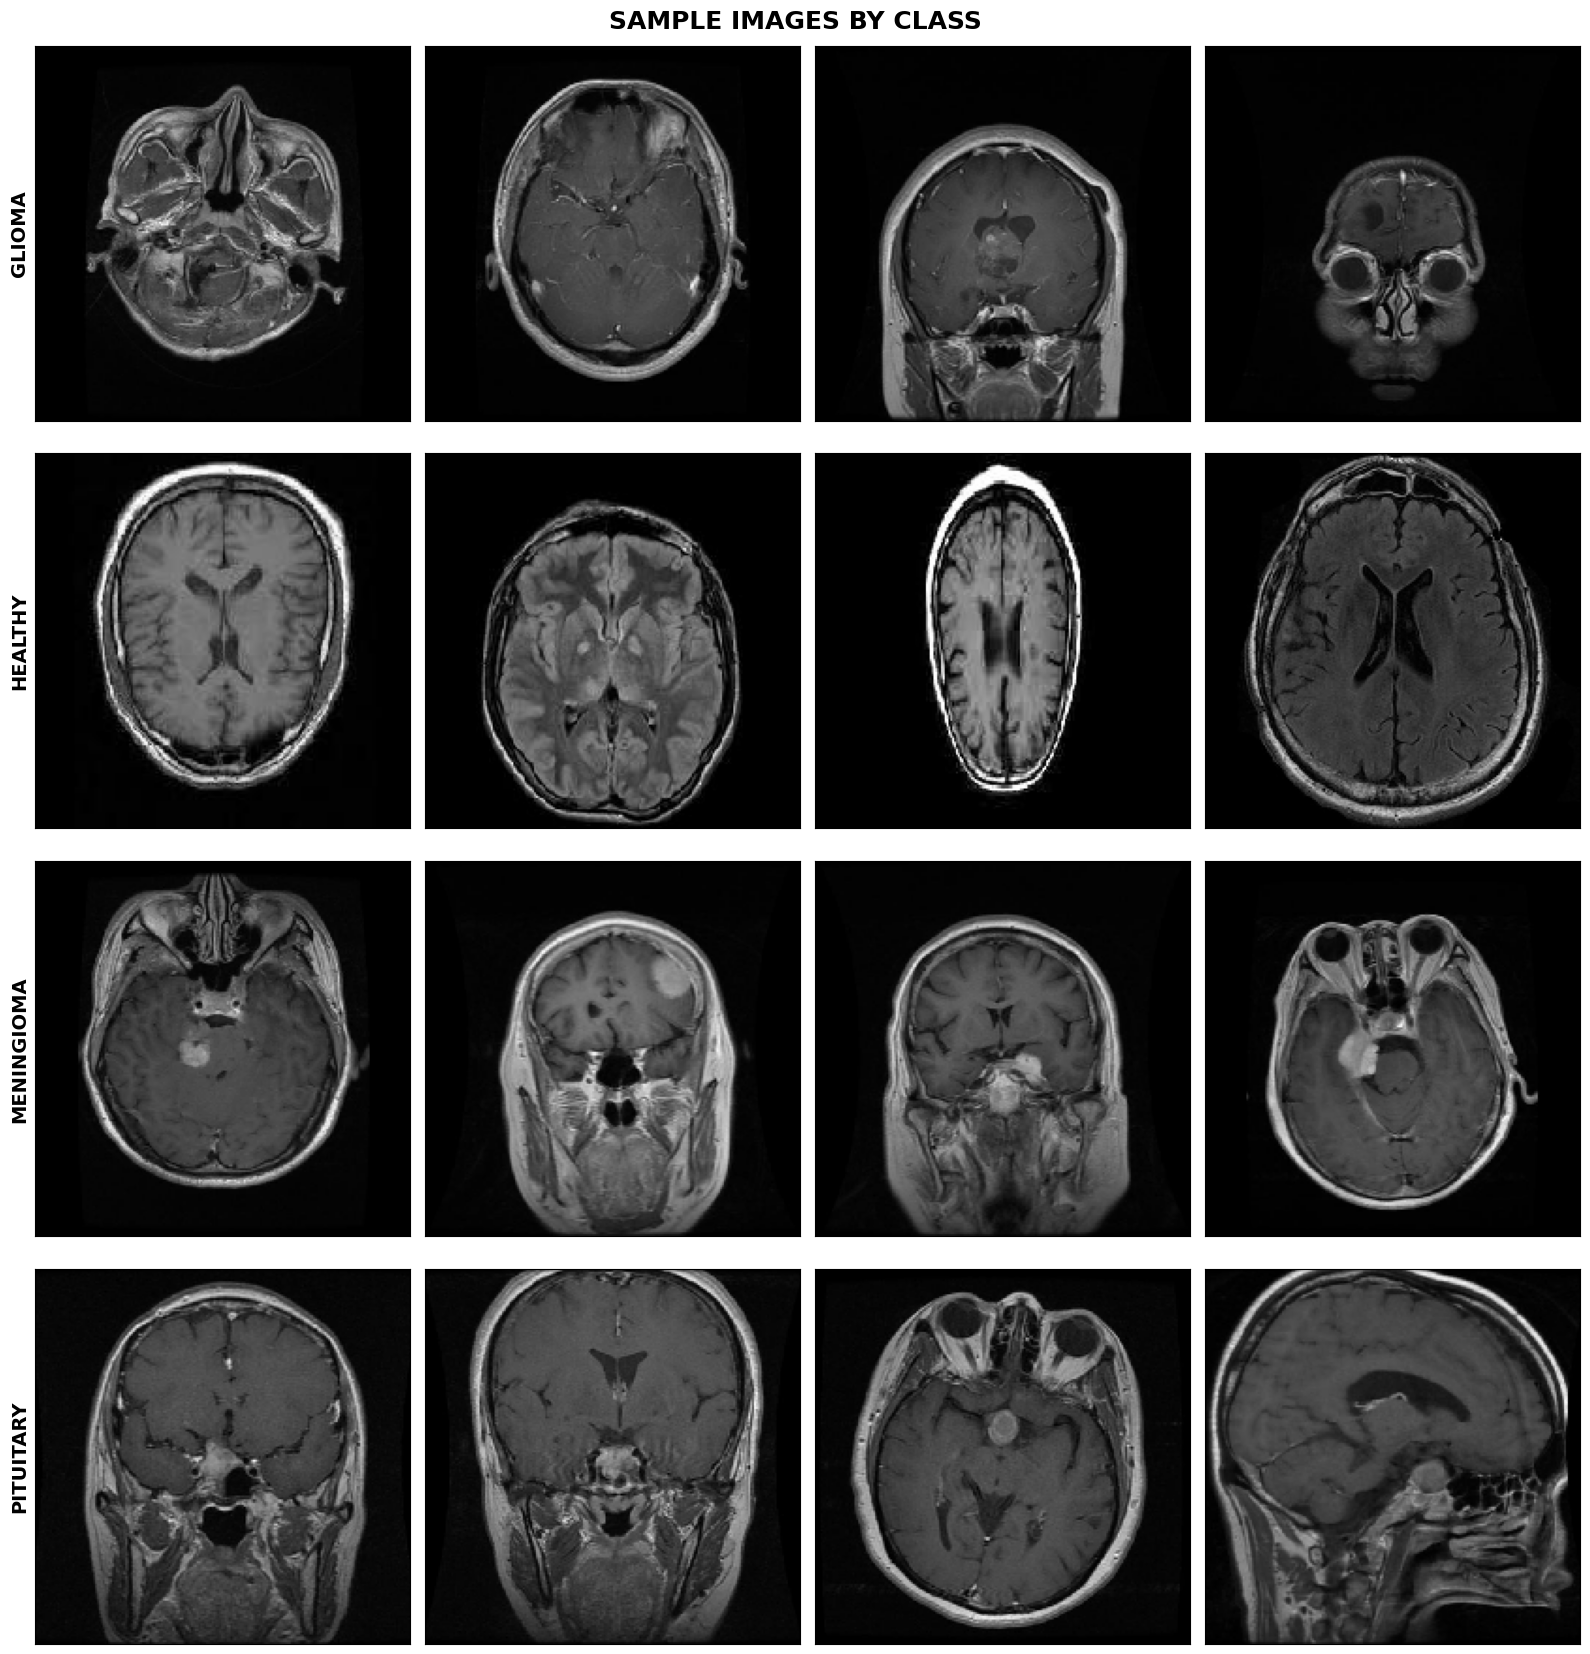

In [27]:
fig, axes = plt.subplots(4, 4, figsize = (16, 17))

for row, class_name in enumerate(classes):

    class_dir = data_dir / class_name
    image_files = list(class_dir.glob("*.jpg"))
    samples = random.sample(image_files, 4)
    
    for col, img_path in enumerate(samples):

        ax = axes[row, col]
        img = tf.keras.utils.load_img(img_path, target_size = (200, 200))
        ax.imshow(img)
        
        if col == 0:
            ax.set_ylabel(class_name.upper(), fontsize = 14, fontweight = "bold")
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("SAMPLE IMAGES BY CLASS", fontsize = 18, fontweight = "bold")
plt.tight_layout()
plt.show()

Conteo de la cantidad de imágenes asociadas a cada clase del conjunto de datos

In [28]:
counts = []

for name in classes:
    class_path = os.path.join(data_dir, name)
    n_images = len(os.listdir(class_path))
    counts.append(n_images)
    print(f"Class {name}: {n_images} images")

Class glioma: 1621 images
Class healthy: 2000 images
Class meningioma: 1645 images
Class pituitary: 1757 images


Visualización de los conteos obtenidos anteriormente en forma de gráfico de barras

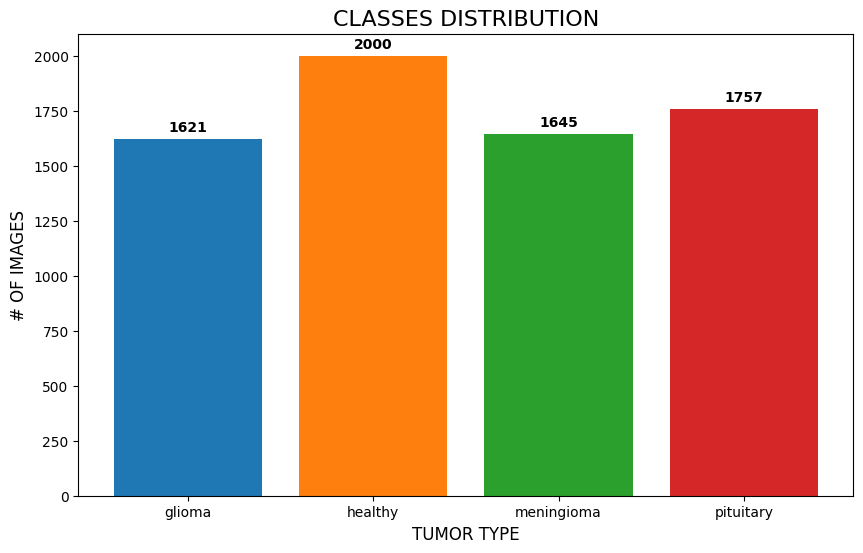

In [29]:
plt.figure(figsize = (10, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"] 
bars = plt.bar(classes, counts, color = colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, yval, ha = "center", va = "bottom", fontweight = "bold")

plt.title("CLASSES DISTRIBUTION", fontsize = 16)
plt.xlabel("TUMOR TYPE", fontsize = 12)
plt.ylabel("# OF IMAGES", fontsize = 12)

plt.show()

|**Pregunta**|**Respuesta**|
|---|---|
|¿El conjunto de datos está balanceado?|Sí, el conjunto de datos está relativamente balanceado, ya que las cuatro clases mantienen una proporción similar (entre el 23% y el 28.5% del total). Sin embargo, es muy recomendable implementar técnicas de Data Augmentation (como rotaciones, zooms o ajustes de brillo). Esto permite compensar las ligeras diferencias numéricas entre categorías, equilibrando mejor el peso de cada clase durante el entrenamiento y mejorando la capacidad del modelo para generalizar ante casos nuevos.|

# **2. Preprocesamiento de datos**

Carga de las imágenes pertenecientes a las distintas clases haciendo uso de la función **image_dataset_from_directory**. Al cargar las imágenes, todas son redimensionadas a un tamaño de **150x150** píxeles y se crean batchs de **32** imágenes cada uno

In [30]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [31]:
full_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED,
    label_mode = "categorical"
)

Found 7023 files belonging to 4 classes.


W0000 00:00:1776205006.314621   22990 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776205006.317822   22990 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776205006.394122   22990 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9256 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


Verificación de que la función identifica correctamente las clases de las imágenes a partir de la estructura de directorios del conjunto de datos

In [32]:
class_names = full_dataset.class_names
print(f"LOADED CLASSES: {class_names}")

LOADED CLASSES: ['glioma', 'healthy', 'meningioma', 'pituitary']


Cálculo de la cantidad de batches que deben pertenecer a cada conjunto de datos en el proceso de división en conjuntos de entrenamiento, validación y test

In [33]:
dataset_size = full_dataset.cardinality().numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

Para evitar la fuga de datos al hacer uso de las funciones **take** y **skip**, se mezclan los elementos del conjunto de datos y se congelan en el orden final logrado. De esta forma se garantiza que no se filten datos entre los diferentes conjuntos a crear

In [34]:
full_dataset = full_dataset.unbatch().shuffle(
    buffer_size = 10000, 
    seed = SEED, 
    reshuffle_each_iteration = False
).batch(BATCH_SIZE)

In [35]:
full_dataset = full_dataset.apply(tf.data.experimental.assert_cardinality(dataset_size))

Creación los conjuntos de entrenamiento, validación y prueba haciendo uso de las funciones **take** y **skip** y de los números de batch calculados anteriormente

In [36]:
train_ds = full_dataset.take(train_size)
remaining = full_dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

Normalización de las imágenes en la totalidad de los conjuntos de datos creados del rango **[0, 255]** al rango **[0 , 1]**

In [37]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [38]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Optimización de los conjuntos de datos para aprovechar la carga de las imágenes en **RAM** y reducir el número de lecturas a realizar sobre el disco del sistema

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

Evaluación de la estructura final de los conjuntos de datos creados

In [40]:
print(f"BATCHES:\n")
print(f"TRAIN: {train_ds.cardinality().numpy()}")
print(f"VALIDATION: {val_ds.cardinality().numpy()}")
print(f"TEST: {test_ds.cardinality().numpy()}")

BATCHES:

TRAIN: 154
VALIDATION: 33
TEST: 33


# **3. Modelo CNN base**

In [41]:
from tensorflow.keras import layers, models

In [42]:
IMG_HEIGHT = 150 
IMG_WIDTH = 150

num_classes = 4

In [43]:
model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),

    layers.Dense(128, activation = "relu"),
    layers.Dense(num_classes, activation = "softmax") 
])

/home/nico/Desktop/Assignment-8/env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(optimizer = "adam",
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits = False),
            metrics = ["accuracy"])

In [46]:
history = model.fit(
    train_ds,           
    validation_data = val_ds,
    epochs = 15,        
    verbose = 1
)

Epoch 1/15


I0000 00:00:1776205008.491439   23135 service.cc:153] XLA service 0x7cb5e40052b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776205008.491467   23135 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1776205008.508900   23135 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776205008.608834   23135 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776205008.613397   23135 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2078__.43
I0000 00:00:1776205009.163286   23263 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 20 bytes spill stores, 16 bytes spill loads



 19/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3585 - loss: 1.8034

I0000 00:00:1776205011.630176   23135 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7188 - loss: 0.7372 - val_accuracy: 0.8390 - val_loss: 0.4501
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8685 - loss: 0.3414 - val_accuracy: 0.9025 - val_loss: 0.2794
Epoch 3/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9261 - loss: 0.2050 - val_accuracy: 0.8598 - val_loss: 0.3502
Epoch 4/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9470 - loss: 0.1523 - val_accuracy: 0.8655 - val_loss: 0.3594
Epoch 5/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9543 - loss: 0.1245 - val_accuracy: 0.9583 - val_loss: 0.1397
Epoch 6/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9742 - loss: 0.0684 - val_accuracy: 0.9744 - val_loss: 0.0969
Epoch 7/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9846 - loss: 0.0483 - val_accuracy: 0.9830 - val_loss: 0.0668
Epoch 8/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9830 - loss: 0.0403 - val_accuracy: 0.9593 - val

In [47]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

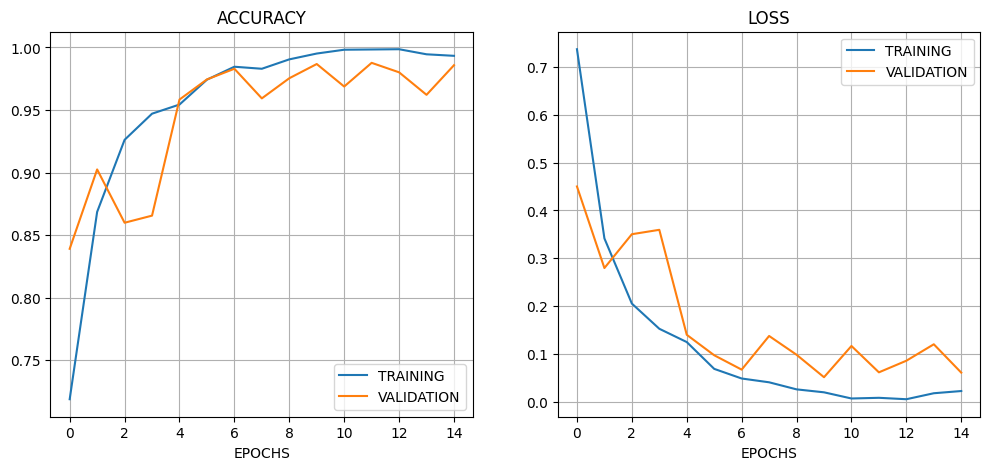

In [48]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = "TRAINING")
plt.plot(epochs_range, val_acc, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = "TRAINING")
plt.plot(epochs_range, val_loss, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()